In [ ]:
import os
import json
import torch

path = "/work/robomimic/trained_models/LNN/u128/03_model_epoch_300_low_dim_v15_success_1.0.pth"
def dump_dict(d, prefix=""):
    if isinstance(d, dict):
        for k, v in d.items():
            name = f"{prefix}{k}"
            if isinstance(v, dict):
                print(f"{name}/")
                dump_dict(v, prefix=name + ".")
            elif torch.is_tensor(v):
                print(f"{name:60s} | shape={tuple(v.shape)} | dtype={v.dtype}")
            else:
                print(f"{name:60s} | type={type(v)}")
    else:
        # dict以外が来たときの保険
        print(f"{prefix.rstrip('.')}: {type(d)}")

ext = os.path.splitext(path)[1].lower()

if ext == ".json":
    with open(path) as f:
        cfg = json.load(f)
    dump_dict(cfg)
else:
    ckpt = torch.load(path, map_location="cpu")
    state = ckpt["state_dict"] if isinstance(ckpt, dict) and "state_dict" in ckpt else ckpt
    dump_dict(state["model"] if isinstance(state, dict) and "model" in state else state)

nets/
nets.policy.core.rnn_cell.gleak                              | shape=(128,) | dtype=torch.float32
nets.policy.core.rnn_cell.vleak                              | shape=(128,) | dtype=torch.float32
nets.policy.core.rnn_cell.cm                                 | shape=(128,) | dtype=torch.float32
nets.policy.core.rnn_cell.sigma                              | shape=(128, 128) | dtype=torch.float32
nets.policy.core.rnn_cell.mu                                 | shape=(128, 128) | dtype=torch.float32
nets.policy.core.rnn_cell.w                                  | shape=(128, 128) | dtype=torch.float32
nets.policy.core.rnn_cell.erev                               | shape=(128, 128) | dtype=torch.float32
nets.policy.core.rnn_cell.sensory_sigma                      | shape=(19, 128) | dtype=torch.float32
nets.policy.core.rnn_cell.sensory_mu                         | shape=(19, 128) | dtype=torch.float32
nets.policy.core.rnn_cell.sensory_w                          | shape=(19, 128) | dtype=tor

In [6]:
import torch
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import torch.nn.functional as F
from matplotlib.colors import TwoSlopeNorm
from matplotlib.ticker import FuncFormatter

def flatten(d, prefix=""):
    out = {}
    for k, v in d.items():
        k = str(k)
        if isinstance(v, dict):
            out.update(flatten(v, prefix + k + "."))
        else:
            out[prefix + k] = v
    return out

def plot_combined_w_and_sensory_w(checkpoint_path: str):
    print(f"Loading checkpoint: {checkpoint_path}")
    try:
        state = torch.load(checkpoint_path, map_location="cpu")
    except FileNotFoundError:
        print("Error: Checkpoint file not found.")
        return

    if "state_dict" in state:
        state = state["state_dict"]

    def flatten(d, prefix=""):
        out = {}
        for k, v in d.items():
            k = str(k)
            if isinstance(v, dict):
                out.update(flatten(v, prefix + k + "."))
            else:
                out[prefix + k] = v
        return out

    flat = flatten(state)

    try:
        w_key = [k for k in flat if k.endswith("rnn_cell.w")][0]
        mask_key = [k for k in flat if k.endswith("rnn_cell.sparsity_mask")][0]
        sensory_w_key = [k for k in flat if k.endswith("rnn_cell.sensory_w")][0]
        sensory_mask_key = [k for k in flat if k.endswith("rnn_cell.sensory_sparsity_mask")][0]
        erev_key = [k for k in flat if k.endswith("rnn_cell.erev")][0]
        sensory_erev_key = [k for k in flat if k.endswith("rnn_cell.sensory_erev")][0]
    except IndexError:
        print("Error: Could not find required keys (rnn_cell.w/sensory_w/mask/erev) in checkpoint.")
        return

    w = flat[w_key]
    mask = flat[mask_key]
    sensory_w = flat[sensory_w_key]
    sensory_mask = flat[sensory_mask_key]
    erev = flat[erev_key]
    sensory_erev = flat[sensory_erev_key]

    # softplus & mask
    w_masked = F.softplus(w) * mask
    sensory_w_masked = F.softplus(sensory_w) * sensory_mask

    # erevをかける
    w_masked_erev = w_masked * erev
    sensory_w_masked_erev = sensory_w_masked * sensory_erev

    # 結合: 行列を1次元にflattenして連結
    combined = torch.cat([w_masked.flatten(), sensory_w_masked.flatten()], dim=0)
    combined_erev = torch.cat([w_masked_erev.flatten(), sensory_w_masked_erev.flatten()], dim=0)

    arr = combined.detach().cpu().numpy()
    arr_nz = arr[arr != 0]
    arr_erev = combined_erev.detach().cpu().numpy()
    arr_erev_nz = arr_erev[arr_erev != 0]

    print(f"Combined shape (with zeros): {arr.shape}")
    print(f"Combined shape (nonzero only): {arr_nz.shape}")
    print(f"Combined (erev) shape (with zeros): {arr_erev.shape}")
    print(f"Combined (erev) shape (nonzero only): {arr_erev_nz.shape}")

    # --- softplus&mask のヒストグラム ---
    if len(arr_nz) > 0:
        plt.figure(figsize=(8, 4.5))
        weights = np.ones_like(arr_nz) / len(arr_nz) * 100
        bins = 200 if np.any(arr_nz < 0) else 100
        plt.hist(arr_nz, bins=bins, weights=weights, color="steelblue", edgecolor="black", alpha=0.9, zorder=2)
        ax = plt.gca()
        ax.xaxis.set_major_formatter(ticker.FormatStrFormatter('%.1f'))
        ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.1f'))
        ax.tick_params(axis="both", labelsize=22, width=1.6)
        for lbl in ax.get_xticklabels() + ax.get_yticklabels():
            lbl.set_fontweight("bold")
        plt.grid(axis="y", linestyle="--", alpha=0.5)
        plt.xlim(-0.05, None)
        plt.tight_layout()
        plt.show()

    # --- erevをかけた後のヒストグラム ---
    if len(arr_erev_nz) > 0:
        plt.figure(figsize=(8, 4.5))
        weights = np.ones_like(arr_erev_nz) / len(arr_erev_nz) * 100
        bins = 100 if np.any(arr_erev_nz < 0) else 100
        plt.hist(arr_erev_nz, bins=bins, weights=weights, color="steelblue", edgecolor="black", alpha=0.9, zorder=2)
        ax = plt.gca()
        ax.xaxis.set_major_formatter(ticker.FormatStrFormatter('%.1f'))
        ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.1f'))
        ax.tick_params(axis="both", labelsize=22, width=1.6)
        for lbl in ax.get_xticklabels() + ax.get_yticklabels():
            lbl.set_fontweight("bold")
        plt.grid(axis="y", linestyle="--", alpha=0.5)
        plt.tight_layout()
        plt.show()

# 使い方例
path = "/work/robomimic/bc_trained_models/lift/ncp-pure-best/ph/unit128/seed1/models/model_epoch_100_low_dim_v15_success_1.0.pth"

plot_combined_w_and_sensory_w(path)

Loading checkpoint: /work/robomimic/bc_trained_models/lift/ncp-pure-best/ph/unit128/seed1/models/model_epoch_100_low_dim_v15_success_1.0.pth
Error: Checkpoint file not found.


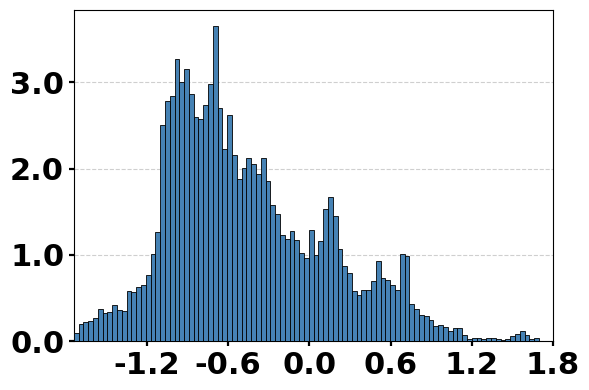

In [7]:
# 重みの可視化
import numpy as np
import json, numpy as np, matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# =========================
# load
# =========================
with open("/work/robomimic/logs/quantize/all/calibration/u256/Seed4.json") as f:
    data = json.load(f)

if not data:
    raise ValueError("data is empty")

def plot_hist_resampled(
    data,
    key="states",
    n_bins=100,
    as_percent=False,
    title=None,
    percent_band=None,   
):
    mins, maxs = [], []
    for d in data:
        if key in d:
            mins.append(d[key]["min"])
            maxs.append(d[key]["max"])
    if not mins:
        raise ValueError(f"{key} not found")

    vmin, vmax = min(mins), max(maxs)
    edges_common = np.linspace(vmin, vmax, n_bins + 1)
    widths = np.diff(edges_common)
    centers = 0.5 * (edges_common[:-1] + edges_common[1:])

    # hist_sum は「density相当」を足し上げている（cnt / bin_width）
    hist_sum = np.zeros(n_bins, dtype=float)

    for d in data:
        if key not in d:
            continue
        h = np.asarray(d[key]["hist"], dtype=float)
        step_min = d[key]["min"]
        step_max = d[key]["max"]

        edges_step = np.linspace(step_min, step_max, len(h) + 1)
        centers_step = 0.5 * (edges_step[:-1] + edges_step[1:])
        widths_step = np.diff(edges_step)

        for c, cnt, w in zip(centers_step, h, widths_step):
            idx = np.searchsorted(edges_common, c, side="right") - 1
            if 0 <= idx < n_bins:
                hist_sum[idx] += (cnt / w) if (w > 0) else cnt

    # ---- 何%の範囲(=CDF)を可視化するために「確率質量」を作る ----
    # density * dx -> mass（各ビンが全体の何%を占めるか）
    mass = hist_sum * widths
    mass_total = mass.sum()

    # percent_band から x 座標を求める（累積分布を edges 上で補間）
    x_lo = x_hi = None
    if percent_band is not None and mass_total > 0:
        lo, hi = percent_band
        lo = float(lo); hi = float(hi)
        if not (0.0 <= lo <= 100.0 and 0.0 <= hi <= 100.0 and lo < hi):
            raise ValueError("percent_band must satisfy 0<=lo<hi<=100")

        cdf_edges = np.concatenate([[0.0], np.cumsum(mass)]) / mass_total * 100.0  # len = n_bins+1
        x_lo = float(np.interp(lo, cdf_edges, edges_common))
        x_hi = float(np.interp(hi, cdf_edges, edges_common))

    # ---- 表示用に % 正規化（y 軸表示） ----
    y = hist_sum.copy()
    if as_percent:
        if y.sum() > 0:
            y = y / y.sum() * 100.0

    plt.figure(figsize=(6, 4))
    plt.bar(
        centers, y, width=widths, align="center",
        edgecolor="black", linewidth=0.6, color="steelblue", zorder=3
    )
    plt.xlim(vmin, vmax)


    # ---- 「何%の範囲はここ」を重ねて表示 ----
    ax = plt.gca()
    ax.xaxis.set_major_formatter(ticker.FormatStrFormatter('%.1f'))
    ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.1f'))

    ax.yaxis.set_major_locator(ticker.MaxNLocator(4))
    ax.xaxis.set_major_locator(ticker.MaxNLocator(6))
    plt.tick_params(axis="both", labelsize=22, width=1.6)
    for lbl in ax.get_xticklabels() + ax.get_yticklabels():
        lbl.set_fontweight("bold")
    plt.grid(axis="y", linestyle="--", alpha=0.6)
    plt.tight_layout()
    plt.show()

# 例: 中央90% (= 5–95%) を表示
plot_hist_resampled(data, key="states", n_bins=100, as_percent=True, title="States histogram")

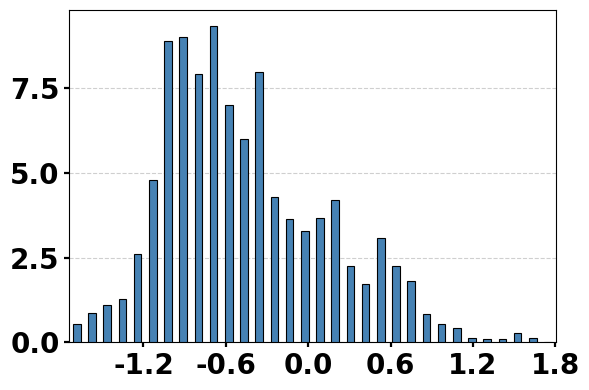

In [8]:
# 重みの量子化
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

def plot_hist_resampled_quantized(
    data,
    key="states",
    n_bins=100,
    n_bits=5,
    as_percent=True,
    title=None,
):
    mins, maxs = [], []
    for d in data:
        if key in d:
            mins.append(d[key]["min"])
            maxs.append(d[key]["max"])
    if not mins:
        raise ValueError(f"{key} not found")

    # 元分布（高分解能）を共通ビンへ再サンプリング
    vmin, vmax = min(mins), max(maxs)
    edges_common = np.linspace(vmin, vmax, n_bins + 1)
    widths_common = np.diff(edges_common)
    centers_common = 0.5 * (edges_common[:-1] + edges_common[1:])
    hist_sum = np.zeros(n_bins, dtype=float)

    for d in data:
        if key not in d:
            continue
        h = np.asarray(d[key]["hist"], dtype=float)
        step_min = d[key]["min"]
        step_max = d[key]["max"]

        edges_step = np.linspace(step_min, step_max, len(h) + 1)
        centers_step = 0.5 * (edges_step[:-1] + edges_step[1:])
        widths_step = np.diff(edges_step)

        for c, cnt, w in zip(centers_step, h, widths_step):
            idx = np.searchsorted(edges_common, c, side="right") - 1
            if 0 <= idx < n_bins:
                hist_sum[idx] += (cnt / w) if (w > 0) else cnt

    # density * dx -> mass
    mass_common = hist_sum * widths_common

    # 4bit量子化ビンへ再集約（2^4 = 16 levels）
    q_levels = 2 ** n_bits
    q_edges = np.linspace(vmin, vmax, q_levels + 1)
    q_widths = np.diff(q_edges)
    q_centers = 0.5 * (q_edges[:-1] + q_edges[1:])
    q_mass = np.zeros(q_levels, dtype=float)

    for c, m in zip(centers_common, mass_common):
        q_idx = np.searchsorted(q_edges, c, side="right") - 1
        q_idx = np.clip(q_idx, 0, q_levels - 1)
        q_mass[q_idx] += m

    y = q_mass.copy()
    if as_percent and y.sum() > 0:
        y = y / y.sum() * 100.0

    plt.figure(figsize=(6, 4))
    plt.bar(
        q_centers,
        y,
        width=q_widths * 0.5,
        align="center",
        edgecolor="black",
        linewidth=0.8,
        color="steelblue",
        zorder=3,
    )
    plt.xlim(vmin, vmax)

    ax = plt.gca()
    ax.xaxis.set_major_formatter(ticker.FormatStrFormatter("%.1f"))
    ax.yaxis.set_major_formatter(ticker.FormatStrFormatter("%.1f"))
    ax.yaxis.set_major_locator(ticker.MaxNLocator(4))
    ax.xaxis.set_major_locator(ticker.MaxNLocator(6))
    plt.tick_params(axis="both", labelsize=20, width=1.6)
    for lbl in ax.get_xticklabels() + ax.get_yticklabels():
        lbl.set_fontweight("bold")
    plt.grid(axis="y", linestyle="--", alpha=0.6)
    plt.tight_layout()
    plt.show()

# 5bit(32レベル)で可視化
plot_hist_resampled_quantized(data, key="states", n_bins=100, n_bits=5, as_percent=True)

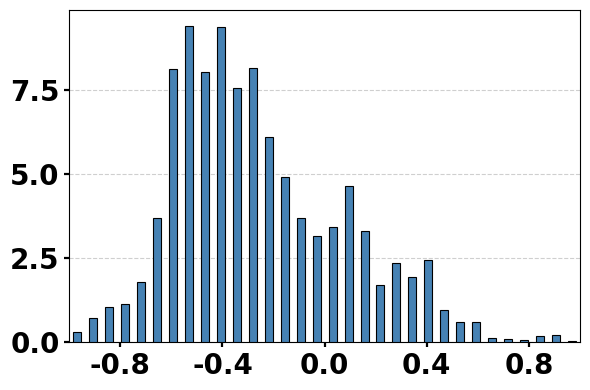

scale = 1.784799


In [9]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker


def plot_hist_resampled_quantized(
    data,
    key="states",
    n_bins=100,
    n_bits=5,
    as_percent=True,
    scale=None,
):
    # ============================================================
    # 1) 全ステップの min / max を集め、共通の再サンプリング範囲を決める
    #    - data は時系列ステップごとのヒストグラム情報の配列
    #    - 各要素 d[key] は {"min", "max", "hist"} を想定
    # ============================================================
    mins, maxs = [], []
    for d in data:
        if key in d:
            mins.append(d[key]["min"])
            maxs.append(d[key]["max"])
    if not mins:
        raise ValueError(f"{key} not found")

    # 全ステップを覆う共通範囲 [vmin, vmax]
    vmin, vmax = min(mins), max(maxs)

    # 共通ビン（高分解能）を作る
    # n_bins=100 なら 100 本の細かいビンで一旦統一する
    edges_common = np.linspace(vmin, vmax, n_bins + 1)
    widths_common = np.diff(edges_common)
    centers_common = 0.5 * (edges_common[:-1] + edges_common[1:])

    # hist_sum は「密度相当」の合算値
    # 後で mass_common = hist_sum * widths_common で確率質量に戻す
    hist_sum = np.zeros(n_bins, dtype=float)

    # ============================================================
    # 2) 各ステップのヒストグラムを共通ビンへ再配置して加算
    #    - 元ヒストが持つビン中心 c がどの共通ビンに入るかで集約
    #    - cnt / w にすることでビン幅差の影響を軽減（密度化）
    # ============================================================
    for d in data:
        if key not in d:
            continue

        h = np.asarray(d[key]["hist"], dtype=float)
        step_min = d[key]["min"]
        step_max = d[key]["max"]

        edges_step = np.linspace(step_min, step_max, len(h) + 1)
        centers_step = 0.5 * (edges_step[:-1] + edges_step[1:])
        widths_step = np.diff(edges_step)

        for c, cnt, w in zip(centers_step, h, widths_step):
            idx = np.searchsorted(edges_common, c, side="right") - 1
            if 0 <= idx < n_bins:
                hist_sum[idx] += (cnt / w) if (w > 0) else cnt

    # 密度 -> 質量（各ビンが持つ重み）
    mass_common = hist_sum * widths_common

    # ============================================================
    # 3) [-1, 1] 正規化のスケールを決定
    #    - scale=None の場合は「実際に質量があるビン中心の最大絶対値」を採用
    #    - その scale で割って [-1,1] にクリップ
    # ============================================================
    if scale is None:
        active = np.abs(centers_common[mass_common > 0])
        scale = float(active.max()) if active.size > 0 else 1.0
    if scale <= 0:
        raise ValueError("scale must be positive")

    centers_norm = np.clip(centers_common / scale, -1.0, 1.0)

    # ============================================================
    # 4) n_bits 量子化ビンへ再集約
    #    - 5bit なら 2^5 = 32 ビン
    #    - 正規化後の値を [-1,1] 上の等間隔ビンに割り当てる
    # ============================================================
    q_levels = 2 ** n_bits
    q_edges = np.linspace(-1.0, 1.0, q_levels + 1)
    q_widths = np.diff(q_edges)
    q_centers = 0.5 * (q_edges[:-1] + q_edges[1:])
    q_mass = np.zeros(q_levels, dtype=float)

    for c, m in zip(centers_norm, mass_common):
        q_idx = np.searchsorted(q_edges, c, side="right") - 1
        q_idx = np.clip(q_idx, 0, q_levels - 1)
        q_mass[q_idx] += m

    # 表示用 y 値（必要なら % 化）
    y = q_mass.copy()
    if as_percent and y.sum() > 0:
        y = y / y.sum() * 100.0

    # ============================================================
    # 5) 可視化（量子化後分布）
    # ============================================================
    plt.figure(figsize=(6, 4))
    plt.bar(
        q_centers,
        y,
        width=q_widths * 0.5,      # 少し隙間を空ける
        align="center",
        edgecolor="black",
        linewidth=0.8,
        color="steelblue",
        zorder=3,
    )
    plt.xlim(-1.0, 1.0)

    ax = plt.gca()
    ax.xaxis.set_major_formatter(ticker.FormatStrFormatter("%.1f"))
    ax.yaxis.set_major_formatter(ticker.FormatStrFormatter("%.1f"))
    ax.yaxis.set_major_locator(ticker.MaxNLocator(4))
    ax.xaxis.set_major_locator(ticker.MaxNLocator(5))
    plt.tick_params(axis="both", labelsize=20, width=1.6)
    for lbl in ax.get_xticklabels() + ax.get_yticklabels():
        lbl.set_fontweight("bold")

    plt.grid(axis="y", linestyle="--", alpha=0.6)
    plt.tight_layout()
    plt.show()

    # 正規化に使用したスケール値を出力
    print(f"scale = {scale:.6f}")


# 5bit(32レベル), [-1,1] に正規化して可視化
plot_hist_resampled_quantized(
    data,
    key="states",
    n_bins=100,
    n_bits=5,
    as_percent=True,
    scale=None,
)

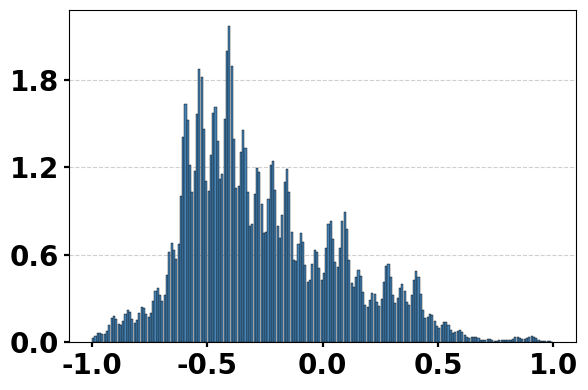

In [21]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker


def plot_hist_resampled_quantized(
    data,
    key="states",
    n_bins=30,
    n_bits=5,
    as_percent=True,
    scale=None,
    std=0.0,
):
    # 1) 共通ビンへ再サンプリング
    mins, maxs = [], []
    for d in data:
        if key in d:
            mins.append(d[key]["min"])
            maxs.append(d[key]["max"])
    if not mins:
        raise ValueError(f"{key} not found")

    vmin, vmax = min(mins), max(maxs)
    edges_common = np.linspace(vmin, vmax, n_bins + 1)
    widths_common = np.diff(edges_common)
    centers_common = 0.5 * (edges_common[:-1] + edges_common[1:])
    hist_sum = np.zeros(n_bins, dtype=float)

    for d in data:
        if key not in d:
            continue

        h = np.asarray(d[key]["hist"], dtype=float)
        step_min = d[key]["min"]
        step_max = d[key]["max"]

        edges_step = np.linspace(step_min, step_max, len(h) + 1)
        centers_step = 0.5 * (edges_step[:-1] + edges_step[1:])
        widths_step = np.diff(edges_step)

        for c, cnt, w in zip(centers_step, h, widths_step):
            idx = np.searchsorted(edges_common, c, side="right") - 1
            if 0 <= idx < n_bins:
                hist_sum[idx] += (cnt / w) if (w > 0) else cnt

    mass_common = hist_sum * widths_common

    # 2) [-1, 1] 正規化
    if scale is None:
        active = np.abs(centers_common[mass_common > 0])
        scale = float(active.max()) if active.size > 0 else 1.0
    if scale <= 0:
        raise ValueError("scale must be positive")

    values = np.clip(centers_common / scale, -1.0, 1.0)

    # 3) 量子化（割合 q_mass を作る）
    q_levels = 2 ** n_bits
    q_edges = np.linspace(-1.0, 1.0, q_levels + 1)
    q_centers = 0.5 * (q_edges[:-1] + q_edges[1:])
    q_mass = np.zeros(q_levels, dtype=float)

    q_idx = np.searchsorted(q_edges, values, side="right") - 1
    q_idx = np.clip(q_idx, 0, q_levels - 1)
    for i, m in zip(q_idx, mass_common):
        q_mass[i] += m

    total_mass = q_mass.sum()
    if total_mass <= 0:
        raise ValueError("quantized mass is empty")

    # 4) ノイズ注入（サンプル増加なし）
    #    各量子化中心の質量を、ガウス核で連続ビンに按分する
    edges_plot = np.linspace(-1.0, 1.0, n_bins + 1)
    centers_plot = 0.5 * (edges_plot[:-1] + edges_plot[1:])
    widths_plot = np.diff(edges_plot)

    y = np.zeros(n_bins, dtype=float)

    if std <= 0.0:
        # ノイズなし: 各量子化中心を最寄り連続ビンへ集約
        idx_plot = np.searchsorted(edges_plot, q_centers, side="right") - 1
        idx_plot = np.clip(idx_plot, 0, n_bins - 1)
        for i, mass in zip(idx_plot, q_mass):
            y[i] += mass
    else:
        for c, mass in zip(q_centers, q_mass):
            if mass <= 0:
                continue
            kernel = np.exp(-0.5 * ((centers_plot - c) / std) ** 2)
            kernel_sum = kernel.sum()
            if kernel_sum > 0:
                kernel = kernel / kernel_sum
                y += mass * kernel

    # 5) [-1,1] 範囲の分布として可視化
    if as_percent and y.sum() > 0:
        y = y / y.sum() * 100.0

    # 6) 可視化
    plt.figure(figsize=(6, 4))
    plt.bar(
        centers_plot,
        y,
        width=widths_plot * 0.9,
        align="center",
        edgecolor="black",
        linewidth=0.3,
        color="steelblue",
        zorder=3,
    )

    ax = plt.gca()
    ax.xaxis.set_major_formatter(ticker.FormatStrFormatter("%.1f"))
    ax.yaxis.set_major_formatter(ticker.FormatStrFormatter("%.1f"))
    ax.yaxis.set_major_locator(ticker.MaxNLocator(4))
    ax.xaxis.set_major_locator(ticker.MaxNLocator(5))
    plt.tick_params(axis="both", labelsize=20, width=1.6)
    for lbl in ax.get_xticklabels() + ax.get_yticklabels():
        lbl.set_fontweight("bold")

    plt.grid(axis="y", linestyle="--", alpha=0.6)
    plt.tight_layout()
    plt.show()


# 実行例
plot_hist_resampled_quantized(
    data,
    key="states",
    n_bins=200,
    n_bits=5,
    as_percent=True,
    scale=None,
    std=0.02,
)

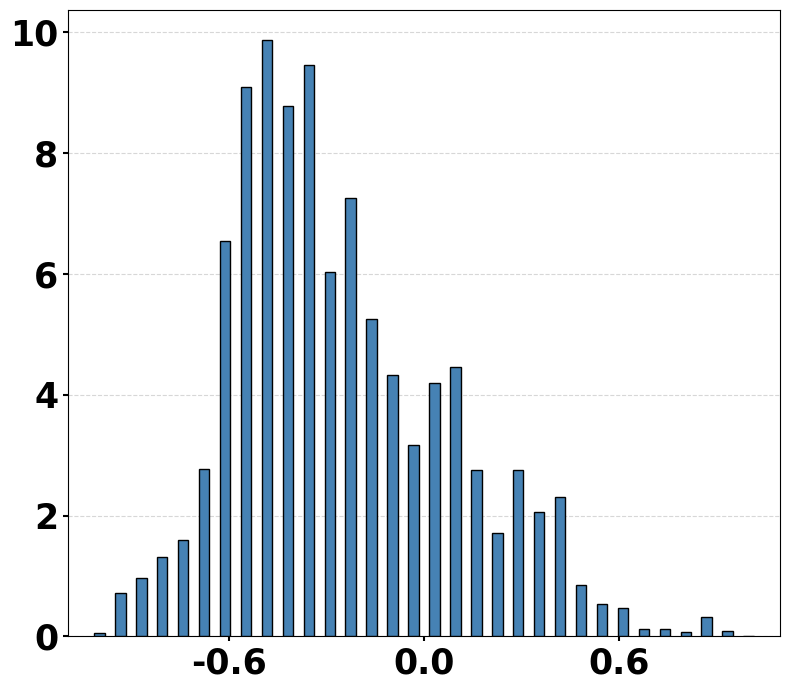

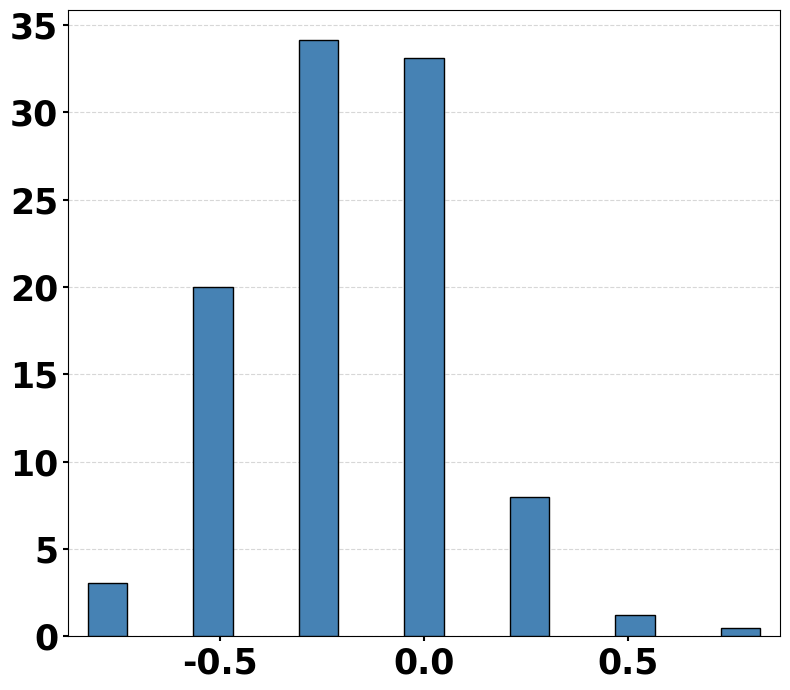

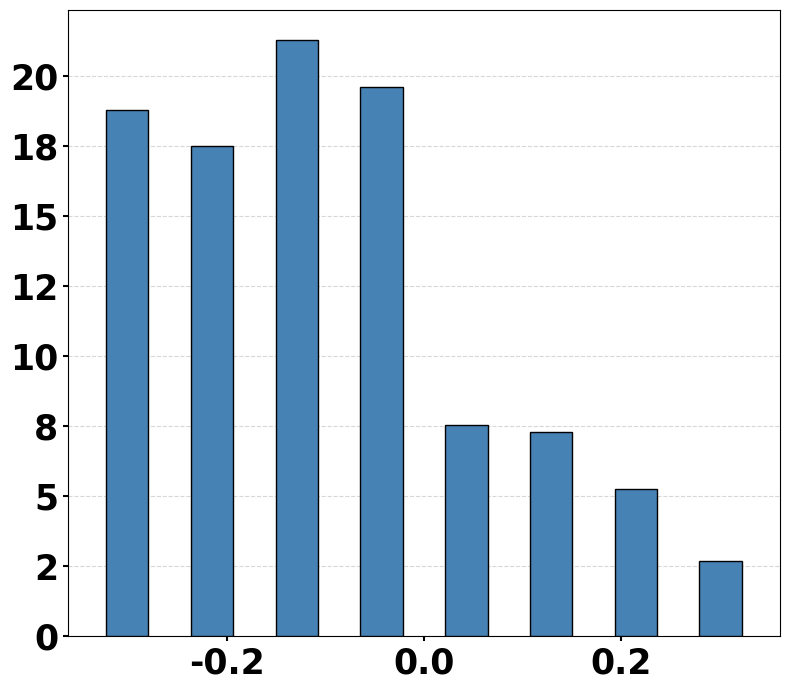

scale = 1.775942
w = 0.064516
MSB bins (value) = [-0.7741935483870968, -0.5161290322580645, -0.25806451612903225, 0.0, 0.25806451612903225, 0.5161290322580645, 0.7741935483870968]
LSB bins (value) = [-0.22580645161290322, -0.16129032258064516, -0.0967741935483871, -0.03225806451612903, 0.03225806451612903, 0.0967741935483871, 0.16129032258064516, 0.22580645161290322]


In [11]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker


def plot_bit_decomposition_5bit_final(data, key="states", n_bins=200, scale=None):
    mins, maxs = [], []
    for d in data:
        if key in d:
            mins.append(d[key]["min"])

            maxs.append(d[key]["max"])
    if not mins:
        raise ValueError(f"{key} not found")

    vmin, vmax = min(mins), max(maxs)
    edges_common = np.linspace(vmin, vmax, n_bins + 1)
    widths_common = np.diff(edges_common)
    centers_common = 0.5 * (edges_common[:-1] + edges_common[1:])
    hist_sum = np.zeros(n_bins, dtype=float)

    for d in data:
        if key not in d:
            continue
        h = np.asarray(d[key]["hist"], dtype=float)
        e_step = np.linspace(d[key]["min"], d[key]["max"], len(h) + 1)
        c_step = 0.5 * (e_step[:-1] + e_step[1:])
        w_step = np.diff(e_step)

        for c, cnt, w_step_i in zip(c_step, h, w_step):
            idx = np.searchsorted(edges_common, c, side="right") - 1
            if 0 <= idx < n_bins:
                hist_sum[idx] += (cnt / w_step_i) if (w_step_i > 0) else cnt

    mass_common = hist_sum * widths_common
    if mass_common.sum() <= 0:
        raise ValueError("mass is empty")

    if scale is None:
        active = np.abs(centers_common[mass_common > 0])
        scale = float(active.max()) if active.size > 0 else 1.0

    val_norm = np.clip(centers_common / scale, -1.0, 1.0)

    n_levels = 32
    w = 2.0 / (n_levels - 1)
    q_idx = np.round((val_norm + 1.0) / w).astype(int)
    q_idx = np.clip(q_idx, 0, n_levels - 1)

    c_code = q_idx.astype(float) - 15.5
    msb_coef = np.trunc(c_code / 4.0) * 4.0
    lsb_coef = c_code - msb_coef

    total_coef = c_code
    msb_bins_coef = np.array([-12, -8, -4, 0, 4, 8, 12], dtype=float)
    lsb_bins_coef = np.array([-3.5, -2.5, -1.5, -0.5, 0.5, 1.5, 2.5, 3.5], dtype=float)

    def aggregate(values, mass, fixed_bins=None):
        bins = np.asarray(fixed_bins, dtype=float) if fixed_bins is not None else np.unique(np.round(values, 10))
        out = np.array([mass[np.isclose(values, b, atol=1e-10)].sum() for b in bins], dtype=float)
        out = out / out.sum() * 100.0 if out.sum() > 0 else out
        return bins, out

    t_x, t_y = aggregate(total_coef, mass_common)
    m_x, m_y = aggregate(msb_coef, mass_common, fixed_bins=msb_bins_coef)
    l_x, l_y = aggregate(lsb_coef, mass_common, fixed_bins=lsb_bins_coef)

    # 係数ではなく実値そのものに変換
    t_x = t_x * w
    m_x = m_x * w
    l_x = l_x * w

    xlims = [(-17 * w, 17 * w), (-13.5 * w, 13.5 * w), (-4.2 * w, 4.2 * w)]

    def plot_single(x, y, width, xlim):
        fig, ax = plt.subplots(figsize=(8, 7))
        ax.bar(x, y, width=width, color="steelblue", edgecolor="black", linewidth=1.0, zorder=3)
        ax.set_xlim(xlim)
        ax.grid(axis="y", linestyle="--", alpha=0.5, zorder=0)
        ax.set_axisbelow(True)
        ax.xaxis.set_major_locator(ticker.MaxNLocator(4))
        ax.xaxis.set_major_formatter(ticker.FormatStrFormatter("%.1f"))
        ax.yaxis.set_major_formatter(ticker.FormatStrFormatter("%.f"))
        ax.tick_params(axis="both", which="major", labelsize=25, width=1.5)
        for lbl in ax.get_xticklabels() + ax.get_yticklabels():
            lbl.set_fontweight("bold")
        plt.tight_layout()
        plt.show()

    plot_single(t_x, t_y, width=0.5 * w, xlim=xlims[0])
    plot_single(m_x, m_y, width=1.5 * w, xlim=xlims[1])
    plot_single(l_x, l_y, width=0.5 * w, xlim=xlims[2])

    print(f"scale = {scale:.6f}")
    print(f"w = {w:.6f}")
    print(f"MSB bins (value) = {(msb_bins_coef * w).tolist()}")
    print(f"LSB bins (value) = {(lsb_bins_coef * w).tolist()}")


# 実行
plot_bit_decomposition_5bit_final(data)

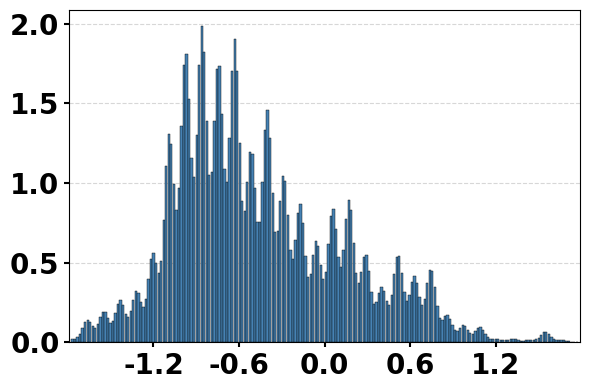

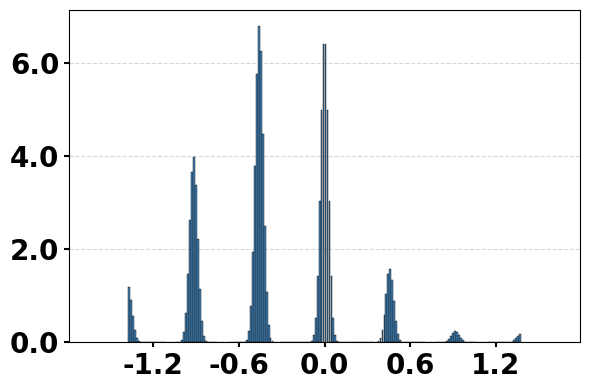

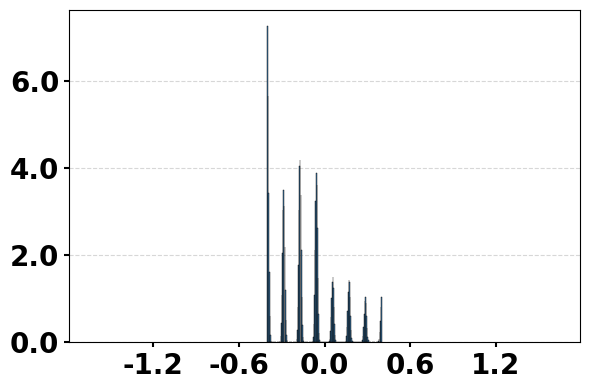

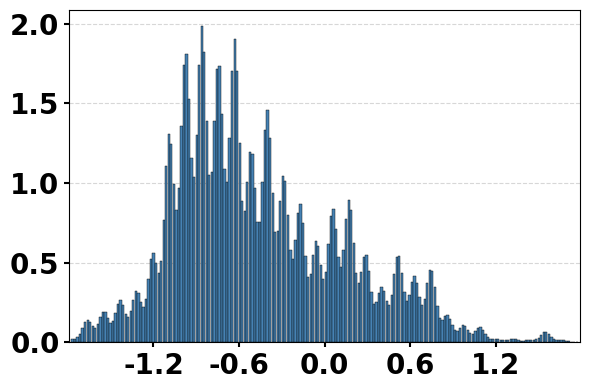

base scale = 1.775942
w = 0.064516
noise std (normalized) = 0.02
Total normalize scale = 1.000000
MSB normalize scale = 0.774194
LSB normalize scale = 0.225806
Reconstructed normalize scale = 1.000000
max |(MSB+LSB)-Total| (value) = 0.000000000000


In [22]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker


def plot_bit_decomposition_with_noise(
    data,
    key="states",
    n_bins=200,
    std=0.02,
    scale=None,
    n_bins_plot=200,
):
    mins, maxs = [], []
    for d in data:
        if key in d:
            mins.append(d[key]["min"])

            maxs.append(d[key]["max"])
    if not mins:
        raise ValueError(f"{key} not found")

    vmin, vmax = min(mins), max(maxs)
    edges_common = np.linspace(vmin, vmax, n_bins + 1)
    widths_common = np.diff(edges_common)
    centers_common = 0.5 * (edges_common[:-1] + edges_common[1:])
    hist_sum = np.zeros(n_bins, dtype=float)

    for d in data:
        if key not in d:
            continue
        h = np.asarray(d[key]["hist"], dtype=float)
        e_step = np.linspace(d[key]["min"], d[key]["max"], len(h) + 1)
        c_step = 0.5 * (e_step[:-1] + e_step[1:])
        w_step = np.diff(e_step)

        for c, cnt, w_step_i in zip(c_step, h, w_step):
            idx = np.searchsorted(edges_common, c, side="right") - 1
            if 0 <= idx < n_bins:
                hist_sum[idx] += (cnt / w_step_i) if (w_step_i > 0) else cnt

    mass_common = hist_sum * widths_common
    if mass_common.sum() <= 0:
        raise ValueError("mass is empty")

    if scale is None:
        active = np.abs(centers_common[mass_common > 0])
        scale = float(active.max()) if active.size > 0 else 1.0

    val_norm = np.clip(centers_common / scale, -1.0, 1.0)

    n_levels = 32
    w = 2.0 / (n_levels - 1)
    q_idx = np.round((val_norm + 1.0) / w).astype(int)
    q_idx = np.clip(q_idx, 0, n_levels - 1)

    c_code = q_idx.astype(float) - 15.5
    total_coef = c_code
    msb_coef = np.trunc(c_code / 4.0) * 4.0
    lsb_coef = c_code - msb_coef
    recon_coef = msb_coef + lsb_coef

    msb_bins_coef = np.array([-12, -8, -4, 0, 4, 8, 12], dtype=float)
    lsb_bins_coef = np.array([-3.5, -2.5, -1.5, -0.5, 0.5, 1.5, 2.5, 3.5], dtype=float)

    def aggregate_mass(values, mass, fixed_bins=None):
        bins = np.asarray(fixed_bins, dtype=float) if fixed_bins is not None else np.unique(np.round(values, 10))
        out_mass = np.array([mass[np.isclose(values, b, atol=1e-10)].sum() for b in bins], dtype=float)
        return bins, out_mass

    def inject_noise_after_normalize(x_value, x_mass, std, n_bins_plot):
        valid = x_mass > 0
        if np.sum(x_mass) <= 0 or not np.any(valid):
            return np.array([0.0]), np.array([0.0]), np.array([1.0]), 1.0

        comp_scale = float(np.max(np.abs(x_value[valid])))
        comp_scale = comp_scale if comp_scale > 0 else 1.0

        x_norm = np.clip(x_value / comp_scale, -1.0, 1.0)

        edges_plot = np.linspace(-1.0, 1.0, n_bins_plot + 1)
        centers_plot = 0.5 * (edges_plot[:-1] + edges_plot[1:])
        widths_plot = np.diff(edges_plot)
        y_mass = np.zeros(n_bins_plot, dtype=float)

        if std <= 0.0:
            idx_plot = np.searchsorted(edges_plot, x_norm, side="right") - 1
            idx_plot = np.clip(idx_plot, 0, n_bins_plot - 1)
            for i, mass_i in zip(idx_plot, x_mass):
                y_mass[i] += mass_i
        else:
            for c_i, mass_i in zip(x_norm, x_mass):
                if mass_i <= 0:
                    continue
                kernel = np.exp(-0.5 * ((centers_plot - c_i) / std) ** 2)
                kernel_sum = kernel.sum()
                if kernel_sum > 0:
                    kernel = kernel / kernel_sum
                    y_mass += mass_i * kernel

        y = y_mass / y_mass.sum() * 100.0 if y_mass.sum() > 0 else y_mass
        x_plot = centers_plot * comp_scale * scale
        width_plot = widths_plot * comp_scale * scale
        return x_plot, y, width_plot, comp_scale

    t_bins_coef, t_mass = aggregate_mass(total_coef, mass_common)
    m_bins_coef, m_mass = aggregate_mass(msb_coef, mass_common, fixed_bins=msb_bins_coef)
    l_bins_coef, l_mass = aggregate_mass(lsb_coef, mass_common, fixed_bins=lsb_bins_coef)
    r_bins_coef, r_mass = aggregate_mass(recon_coef, mass_common)

    t_x, t_y, t_w, t_scale = inject_noise_after_normalize(t_bins_coef * w, t_mass, std, n_bins_plot)
    m_x, m_y, m_w, m_scale = inject_noise_after_normalize(m_bins_coef * w, m_mass, std, n_bins_plot)
    l_x, l_y, l_w, l_scale = inject_noise_after_normalize(l_bins_coef * w, l_mass, std, n_bins_plot)
    r_x, r_y, r_w, r_scale = inject_noise_after_normalize(r_bins_coef * w, r_mass, std, n_bins_plot)

    def plot_single(x, y, width):
        fig, ax = plt.subplots(figsize=(6, 4))
        ax.bar(x, y, width=width * 0.9, color="steelblue", edgecolor="black", linewidth=0.3, zorder=3)
        ax.grid(axis="y", linestyle="--", alpha=0.5, zorder=0)
        ax.set_axisbelow(True)
        ax.tick_params(axis="both", which="major", labelsize=20, width=1.5)
        ax.xaxis.set_major_locator(ticker.MaxNLocator(4))
        ax.set_xlim(-1.79, 1.79) 
        ax.xaxis.set_major_locator(ticker.MultipleLocator(0.6))
        ax.xaxis.set_major_formatter(ticker.FormatStrFormatter("%.1f"))
        ax.yaxis.set_major_formatter(ticker.FormatStrFormatter("%.1f"))
        for lbl in ax.get_xticklabels() + ax.get_yticklabels():
            lbl.set_fontweight("bold")
        plt.tight_layout()
        plt.show()

    plot_single(t_x, t_y, t_w)
    plot_single(m_x, m_y, m_w)
    plot_single(l_x, l_y, l_w)
    plot_single(r_x, r_y, r_w)

    recon_err = np.max(np.abs((recon_coef - total_coef) * w))
    print(f"base scale = {scale:.6f}")
    print(f"w = {w:.6f}")
    print(f"noise std (normalized) = {std}")
    print(f"Total normalize scale = {t_scale:.6f}")
    print(f"MSB normalize scale = {m_scale:.6f}")
    print(f"LSB normalize scale = {l_scale:.6f}")
    print(f"Reconstructed normalize scale = {r_scale:.6f}")
    print(f"max |(MSB+LSB)-Total| (value) = {recon_err:.12f}")


# 実行例（前と同じ方式でノイズ注入）
plot_bit_decomposition_with_noise(data, std=0.02)
